# Anime Recommendation System - EDA & Data Preparation

## tl;dr

The 7,813,737 raw interactions produced 6,337,234 explicit 1--10 interactions after removing 1,476,496 watched-but-unrated (`-1`) records and merging 7 duplicate rows. The matrix has 69,600 users, 9,927 rated anime, and 0.9172% density. Ratings average 7.81 (mode 8); user activity has median 45, P90 230, and P99 640 ratings. The prepared metadata contains 12,294 unique anime records.

This notebook prepares the reproducible SVD input, keeps display metadata separate, and never samples, filters minimum interactions, splits data, normalizes ratings, or trains a model.

## Context & Outputs

This notebook is the reproducible input-preparation step for collaborative filtering. It reads `datasets/anime.csv` and `datasets/rating.csv`, audits their quality, creates cleaned data, and saves three EDA figures.

**Inputs:** `datasets/anime.csv`, `datasets/rating.csv`  
**Outputs:** `data/ratings_clean.csv`, `data/anime_clean.csv`, `outputs/figures/*.png`

`rating = -1` means that a user watched an anime without giving an explicit score. It is not a dislike or a numeric rating, so it is excluded from SVD inputs and evaluation metrics. Raw ratings may require substantial RAM; this notebook intentionally reads the complete files to preserve an auditable baseline.

**Boundary with Notebook 02:** this notebook does not sample interactions, filter users/items by interaction count, split train/test data, scale ratings, or train a model.

## Analysis Questions

This notebook answers four questions:

1. Which data-quality issues in the raw files must be addressed before building a recommender system?
2. After cleaning, how many users, anime, and explicit-rating interactions remain?
3. How sparse is the user--anime matrix, and what patterns characterize rating and user-rating activity?
4. Which data characteristics must inform Notebook 02, including sampling, filtering, train/test splitting, and SVD?

**Scope:** This is a data-preparation and exploratory-data-analysis notebook. It does not evaluate predictive accuracy, compare models, or make causal claims.

## Setup

The cleaning is deterministic. `SEED = 42` is declared here for project-wide consistency, even though this notebook uses no random operation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

SEED = 42
RATING_MIN = 1
RATING_MAX = 10

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "datasets").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_ANIME_PATH = PROJECT_ROOT / "datasets" / "anime.csv"
RAW_RATINGS_PATH = PROJECT_ROOT / "datasets" / "rating.csv"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": False})
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

### Helper functions

These small functions have no hidden state and keep quality checks, chart export, and the audit log consistent.

In [2]:
def require_columns(df, required_columns, dataset_name):
    missing = sorted(set(required_columns) - set(df.columns))
    if missing:
        raise ValueError(
            f"{dataset_name} is missing required columns: {missing}. "
            f"Available columns: {df.columns.tolist()}"
        )


def quality_snapshot(df, dataset_name, key_columns):
    # Return a compact, inspectable quality profile for a DataFrame.
    rows = [
        {"dataset": dataset_name, "metric": "rows", "value": len(df)},
        {"dataset": dataset_name, "metric": "columns", "value": len(df.columns)},
        {"dataset": dataset_name, "metric": "exact duplicate rows", "value": int(df.duplicated().sum())},
        {
            "dataset": dataset_name,
            "metric": f"duplicate keys ({', '.join(key_columns)})",
            "value": int(df.duplicated(key_columns).sum()),
        },
    ]
    for column in df.columns:
        rows.append(
            {
                "dataset": dataset_name,
                "metric": f"missing values: {column}",
                "value": int(df[column].isna().sum()),
            }
        )
        rows.append(
            {
                "dataset": dataset_name,
                "metric": f"dtype: {column}",
                "value": str(df[column].dtype),
            }
        )
    return pd.DataFrame(rows)


def save_figure(filename):
    output_path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return output_path


def display_change_log(change_log):
    audit = pd.DataFrame(change_log)
    display(audit)
    return audit


def add_change(change_log, dataset, step, rows_before, rows_after, reason):
    change_log.append(
        {
            "dataset": dataset,
            "step": step,
            "rows_before": int(rows_before),
            "rows_after": int(rows_after),
            "rows_removed_or_merged": int(rows_before - rows_after),
            "reason": reason,
        }
    )


def file_size_mb(path):
    return path.stat().st_size / (1024 ** 2)

## Load & Initial Data Overview

### Read raw CSV files

IDs use nullable integer types so missing values remain observable. User ratings remain strings until validation, preventing early coercion from hiding malformed values.

In [3]:
for input_path in (RAW_ANIME_PATH, RAW_RATINGS_PATH):
    if not input_path.exists():
        raise FileNotFoundError(
            f"Required input file not found: {input_path.resolve()}. "
            "Run the notebook from the project root."
        )

anime_raw = pd.read_csv(
    RAW_ANIME_PATH,
    dtype={"anime_id": "Int64", "name": "string", "genre": "string", "type": "string"},
)
ratings_raw = pd.read_csv(
    RAW_RATINGS_PATH,
    dtype={"user_id": "Int64", "anime_id": "Int64", "rating": "string"},
)

require_columns(anime_raw, ["anime_id", "name", "genre", "type", "episodes", "rating", "members"], "anime.csv")
require_columns(ratings_raw, ["user_id", "anime_id", "rating"], "rating.csv")

print(f"anime.csv: {anime_raw.shape[0]:,} rows × {anime_raw.shape[1]} columns ({file_size_mb(RAW_ANIME_PATH):,.2f} MiB)")
print(f"rating.csv: {ratings_raw.shape[0]:,} rows × {ratings_raw.shape[1]} columns ({file_size_mb(RAW_RATINGS_PATH):,.2f} MiB)")

anime.csv: 12,294 rows × 7 columns (0.89 MiB)
rating.csv: 7,813,737 rows × 3 columns (106.24 MiB)


### Schema and preview

Preview only a few records and bounded descriptive statistics. IDs are identifiers, not numeric features; user rating is the future collaborative-filtering signal.

In [4]:
display(Markdown("#### anime.csv preview"))
display(anime_raw.head())
display(anime_raw.dtypes.rename("dtype").to_frame())
display(anime_raw.describe(include="all").transpose().head(10))

display(Markdown("#### rating.csv preview"))
display(ratings_raw.head())
display(ratings_raw.dtypes.rename("dtype").to_frame())
display(ratings_raw.describe(include="all").transpose())

print("Roles — IDs: user_id, anime_id | numeric: user rating, anime average rating, members, episodes (after parsing) | text: name, genre, type")

#### anime.csv preview

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.370,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.260,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.250,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.170,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.160,151266


,dtype
anime_id,Int64
name,string[python]
genre,string[python]
type,string[python]
episodes,object
rating,float64
members,int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
anime_id,"12,294.000",<NA>,<NA>,<NA>,"14,058.222","11,455.295",1.000,"3,484.250","10,260.500","24,794.500","34,527.000"
name,12294,12292,Shi Wan Ge Leng Xiaohua,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,12232,3264,Hentai,823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,12269,6,TV,3787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
episodes,12294,187,1,5677,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,"12,064.000",NaN,NaN,NaN,6.474,1.027,1.670,5.880,6.570,7.180,10.000
members,"12,294.000",NaN,NaN,NaN,"18,071.339","54,820.677",5.000,225.000,"1,550.000","9,437.000","1,013,917.000"


#### rating.csv preview

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


,dtype
user_id,Int64
anime_id,Int64
rating,string[python]


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,"7,813,737.000",<NA>,<NA>,<NA>,"36,727.957","20,997.946",1.000,"18,974.000","36,791.000","54,757.000","73,516.000"
anime_id,"7,813,737.000",<NA>,<NA>,<NA>,"8,909.072","8,883.950",1.000,"1,240.000","6,213.000","14,093.000","34,519.000"
rating,7813737,11,8,1646019,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Roles — IDs: user_id, anime_id | numeric: user rating, anime average rating, members, episodes (after parsing) | text: name, genre, type


### Initial quality report

This snapshot is retained in memory for the before-versus-after comparison. The checks include sentinel `-1`, candidate-key duplication, metadata coverage, empty display strings, and unusual episode values.

In [5]:
quality_before = {
    "ratings": quality_snapshot(ratings_raw, "rating.csv (raw)", ["user_id", "anime_id"]),
    "anime": quality_snapshot(anime_raw, "anime.csv (raw)", ["anime_id"]),
}
display(pd.concat(quality_before.values(), ignore_index=True))

raw_rating_numeric = pd.to_numeric(ratings_raw["rating"], errors="coerce")
metadata_ids = set(anime_raw["anime_id"].dropna().astype("int64"))
empty_text_counts = {
    column: int(anime_raw[column].astype("string").str.strip().eq("").sum())
    for column in ["name", "genre", "type"]
}
episodes_numeric = pd.to_numeric(anime_raw["episodes"], errors="coerce")

initial_checks = pd.DataFrame(
    {
        "check": [
            "ratings with missing user_id", "ratings with missing anime_id", "ratings with missing/unparseable value",
            "ratings with sentinel -1", "duplicate (user_id, anime_id)", "ratings anime_id absent from metadata",
            "metadata anime_id with no rating", "metadata missing name", "metadata missing genre", "metadata missing type",
            "metadata empty name", "metadata empty genre", "metadata empty type", "episodes missing/unparseable", "episodes <= 0",
        ],
        "count": [
            int(ratings_raw["user_id"].isna().sum()), int(ratings_raw["anime_id"].isna().sum()), int(raw_rating_numeric.isna().sum()),
            int(raw_rating_numeric.eq(-1).sum()), int(ratings_raw.duplicated(["user_id", "anime_id"]).sum()),
            int((~ratings_raw["anime_id"].isin(metadata_ids)).sum()),
            int((~anime_raw["anime_id"].isin(ratings_raw["anime_id"].dropna().unique())).sum()),
            int(anime_raw["name"].isna().sum()), int(anime_raw["genre"].isna().sum()), int(anime_raw["type"].isna().sum()),
            empty_text_counts["name"], empty_text_counts["genre"], empty_text_counts["type"],
            int(episodes_numeric.isna().sum()), int(episodes_numeric.le(0).sum()),
        ],
    }
)
display(initial_checks)
display(raw_rating_numeric.value_counts(dropna=False).sort_index().rename("raw_rating_count").to_frame())

,dataset,metric,value
0,rating.csv (raw),rows,7813737
1,rating.csv (raw),columns,3
2,rating.csv (raw),exact duplicate rows,1
3,rating.csv (raw),"duplicate keys (user_id, anime_id)",7
4,rating.csv (raw),missing values: user_id,0
5,rating.csv (raw),dtype: user_id,Int64
6,rating.csv (raw),missing values: anime_id,0
7,rating.csv (raw),dtype: anime_id,Int64
8,rating.csv (raw),missing values: rating,0
9,rating.csv (raw),dtype: rating,string


,check,count
0,ratings with missing user_id,0
1,ratings with missing anime_id,0
2,ratings with missing/unparseable value,0
3,ratings with sentinel -1,1476496
4,"duplicate (user_id, anime_id)",7
5,ratings anime_id absent from metadata,10
6,metadata anime_id with no rating,1097
7,metadata missing name,0
8,metadata missing genre,62
9,metadata missing type,25


,raw_rating_count
rating,
-1,1476496
1,16649
2,23150
3,41453
4,104291
5,282806
6,637775
7,1375287
8,1646019


### Initial data-quality summary

- The raw dataset contains **12,294** anime records (7 columns) and **7,813,737** user--anime interactions (3 columns). The `user_id` and `anime_id` keys in the ratings table are complete, and all rating values can be parsed.
- The main issue is **1,476,496** records with `rating = -1` (18.90% of interactions). This means *watched but not rated* and is not a valid score for collaborative-filtering training or evaluation.
- The ratings table contains **7** duplicate `(user_id, anime_id)` keys, including one fully duplicate row, and 10 ratings refer to anime that are absent from the metadata.
- Metadata has unique `anime_id` values and no missing names, but `genre` (62), `type` (25), anime average rating (230), and episode values (340 unparseable values) have missing or unusable entries. These gaps affect display and interpretation; they do not by themselves invalidate an explicit rating.

**Assessment:** The dataset is sufficiently large and contains a rich explicit-rating signal, but the `-1` sentinel must be separated from the 1--10 scale, interaction keys must be made unique, and metadata coverage must be considered before results are displayed or interpreted.

## Cleaning Decisions & Data Preparation

1. `-1` means watched but not explicitly rated, so it is excluded from training and all evaluation metrics.
2. Raw explicit ratings are integer values from 1 to 10. After duplicate user–anime interactions are consolidated by their mean, final ratings may be fractional but remain within the valid [1, 10] range.
3. Multiple rows for one `(user_id, anime_id)` pair are consolidated by their mean rating, retaining one observation without arbitrarily preferring a row.
4. User/item interaction counts are naturally long-tailed in recommender data. They are preserved here; Notebook 02 may apply resource-aware interaction filters separately.
5. Metadata is cleaned only for display. Missing names/genres are never invented, and the average rating in `anime.csv` is not a training target.
6. Explicit user ratings remain on their original 1--10 ordinal scale: no clipping, z-score, or IQR treatment is applied.


### Normalize and validate ratings

Each removal is an auditable, business-defined validation decision.

In [6]:
change_log = []
ratings_work = ratings_raw.copy()
ratings_work[["user_id", "anime_id", "rating"]] = ratings_work[["user_id", "anime_id", "rating"]].apply(
    pd.to_numeric, errors="coerce"
)

before = len(ratings_work)
ratings_work = ratings_work.dropna(subset=["user_id", "anime_id", "rating"]).copy()
add_change(
    change_log, "ratings", "Remove missing or non-numeric required fields", before, len(ratings_work),
    "SVD interactions require a parseable user ID, anime ID, and explicit rating value.",
)

before = len(ratings_work)
ratings_work = ratings_work.loc[ratings_work["rating"].ne(-1)].copy()
add_change(
    change_log, "ratings", "Remove watched-but-unrated sentinel (-1)", before, len(ratings_work),
    "-1 encodes watched without an explicit score; it is neither a dislike nor a numeric rating.",
)

valid_explicit_rating = (
    ratings_work["rating"].between(RATING_MIN, RATING_MAX)
    & np.isclose(ratings_work["rating"] % 1, 0)
)
before = len(ratings_work)
ratings_work = ratings_work.loc[valid_explicit_rating].copy()
add_change(
    change_log, "ratings", "Remove invalid explicit ratings", before, len(ratings_work),
    "Only integer explicit scores in the inclusive 1--10 domain are valid for collaborative filtering.",
)

ratings_work[["user_id", "anime_id"]] = ratings_work[["user_id", "anime_id"]].astype("int64")
ratings_work["rating"] = ratings_work["rating"].astype("int64")
assert ratings_work["rating"].between(RATING_MIN, RATING_MAX).all()

### Resolve interaction duplicates

A user-item pair must have one value. Duplicate observations are averaged after validation; final ratings may be fractional, but they remain within the valid [1, 10] domain.


In [7]:
before = len(ratings_work)
duplicate_key_rows = int(ratings_work.duplicated(["user_id", "anime_id"], keep=False).sum())
ratings_clean = (
    ratings_work.groupby(["user_id", "anime_id"], as_index=False, sort=False)["rating"]
    .mean()
)
add_change(
    change_log, "ratings", "Merge duplicate user-anime interactions", before, len(ratings_clean),
    "Use the mean rating per (user_id, anime_id) instead of arbitrarily retaining one duplicate row.",
)
print(f"Rows participating in duplicate keys before merge: {duplicate_key_rows:,}")
assert not ratings_clean.duplicated(["user_id", "anime_id"]).any()
assert ratings_clean["rating"].between(RATING_MIN, RATING_MAX).all()

Rows participating in duplicate keys before merge: 14


### Clean metadata for display

Metadata is normalized for recommendation labels only. Missing display values remain missing; `anime_average_rating` is explicitly named to avoid confusion with user ratings.

In [8]:
metadata_work = anime_raw.copy()
metadata_work["_source_order"] = np.arange(len(metadata_work))
metadata_work["anime_id"] = pd.to_numeric(metadata_work["anime_id"], errors="coerce")
valid_metadata_id = metadata_work["anime_id"].notna() & np.isclose(metadata_work["anime_id"].fillna(0) % 1, 0)
before = len(metadata_work)
metadata_work = metadata_work.loc[valid_metadata_id].copy()
add_change(
    change_log, "metadata", "Remove missing or invalid anime_id", before, len(metadata_work),
    "Metadata needs one valid integer anime_id for joins and recommendation display.",
)
metadata_work["anime_id"] = metadata_work["anime_id"].astype("int64")

for column in ["name", "genre", "type"]:
    metadata_work[column] = metadata_work[column].astype("string").str.strip().replace("", pd.NA)

metadata_work["_metadata_completeness"] = metadata_work[["name", "genre", "type"]].notna().sum(axis=1)
before = len(metadata_work)
metadata_work = (
    metadata_work.sort_values(
        ["anime_id", "_metadata_completeness", "_source_order"],
        ascending=[True, False, True],
        kind="stable",
    )
    .drop_duplicates("anime_id", keep="first")
    .copy()
)
add_change(
    change_log, "metadata", "Resolve duplicate anime metadata", before, len(metadata_work),
    "Keep the most complete display record per anime_id, breaking ties by stable source order.",
)

for column in ["episodes", "rating", "members"]:
    metadata_work[column] = pd.to_numeric(metadata_work[column], errors="coerce")

anime_clean = (
    metadata_work.rename(columns={"rating": "anime_average_rating"})[
        ["anime_id", "name", "genre", "type", "episodes", "anime_average_rating", "members"]
    ]
    .sort_values("anime_id", kind="stable")
    .reset_index(drop=True)
)
display(anime_clean.isna().sum().rename("missing_values").to_frame())
assert anime_clean["anime_id"].is_unique

,missing_values
anime_id,0
name,0
genre,62
type,25
episodes,340
anime_average_rating,230
members,0


### Referential integrity and final validation

Ratings without metadata remain valid SVD interactions. They are reported because recommendations for them cannot show a title or genre without fallback text.

In [9]:
metadata_anime_ids = set(anime_clean["anime_id"])
rating_anime_ids = set(ratings_clean["anime_id"])
unmatched_rating_anime_ids = sorted(rating_anime_ids - metadata_anime_ids)
metadata_without_ratings = sorted(metadata_anime_ids - rating_anime_ids)
print(f"Rated anime IDs absent from metadata (retained for SVD): {len(unmatched_rating_anime_ids):,}")
print(f"Metadata anime IDs without explicit ratings: {len(metadata_without_ratings):,}")

quality_after = {
    "ratings": quality_snapshot(ratings_clean, "ratings_clean", ["user_id", "anime_id"]),
    "anime": quality_snapshot(anime_clean, "anime_clean", ["anime_id"]),
}
display(pd.concat(quality_after.values(), ignore_index=True))

unique_users = ratings_clean["user_id"].nunique()
unique_rated_anime = ratings_clean["anime_id"].nunique()
matrix_density = len(ratings_clean) / (unique_users * unique_rated_anime)
before_after = pd.DataFrame(
    {
        "metric": ["interactions", "unique users", "unique rated anime", "matrix density", "metadata anime"],
        "before": [
            len(ratings_raw), ratings_raw["user_id"].nunique(dropna=True), ratings_raw["anime_id"].nunique(dropna=True),
            np.nan, anime_raw["anime_id"].nunique(dropna=True),
        ],
        "after": [len(ratings_clean), unique_users, unique_rated_anime, matrix_density, anime_clean["anime_id"].nunique()],
    }
)
display(before_after)
change_log_df = display_change_log(change_log)

assert not ratings_clean["rating"].eq(-1).any()
assert ratings_clean["rating"].between(RATING_MIN, RATING_MAX).all()
assert not ratings_clean.duplicated(["user_id", "anime_id"]).any()
assert ratings_clean[["user_id", "anime_id", "rating"]].notna().all().all()
assert anime_clean["anime_id"].is_unique

Rated anime IDs absent from metadata (retained for SVD): 1
Metadata anime IDs without explicit ratings: 2,368


,dataset,metric,value
0,ratings_clean,rows,6337234
1,ratings_clean,columns,3
2,ratings_clean,exact duplicate rows,0
3,ratings_clean,"duplicate keys (user_id, anime_id)",0
4,ratings_clean,missing values: user_id,0
5,ratings_clean,dtype: user_id,int64
6,ratings_clean,missing values: anime_id,0
7,ratings_clean,dtype: anime_id,int64
8,ratings_clean,missing values: rating,0
9,ratings_clean,dtype: rating,float64


,metric,before,after
0,interactions,"7,813,737.000","6,337,234.000"
1,unique users,"73,515.000","69,600.000"
2,unique rated anime,"11,200.000","9,927.000"
3,matrix density,NaN,0.009
4,metadata anime,"12,294.000","12,294.000"


,dataset,step,rows_before,rows_after,rows_removed_or_merged,reason
0,ratings,Remove missing or non-numeric required fields,7813737,7813737,0,"SVD interactions require a parseable user ID, ..."
1,ratings,Remove watched-but-unrated sentinel (-1),7813737,6337241,1476496,-1 encodes watched without an explicit score; ...
2,ratings,Remove invalid explicit ratings,6337241,6337241,0,Only integer explicit scores in the inclusive ...
3,ratings,Merge duplicate user-anime interactions,6337241,6337234,7,"Use the mean rating per (user_id, anime_id) in..."
4,metadata,Remove missing or invalid anime_id,12294,12294,0,Metadata needs one valid integer anime_id for ...
5,metadata,Resolve duplicate anime metadata,12294,12294,0,Keep the most complete display record per anim...


### Cleaning results summary

The pipeline: (1) parses and validates required fields, (2) removes the `-1` sentinel, (3) retains only raw integer ratings from 1 to 10, (4) consolidates duplicate `(user_id, anime_id)` records using their **mean**, and (5) standardizes display metadata without imputing missing values. No missing, invalid, or out-of-range explicit ratings were removed; the observed changes were the removal of **1,476,496** sentinel records and consolidation of **7** duplicate rows.

After cleaning, the interaction dataset contains **6,337,234** rows, **69,600** users, and **9,927** rated anime. All keys and final ratings are complete, no duplicate user--anime pairs remain, and final ratings remain in the [1, 10] range; duplicate consolidation produces two fractional values: `6.5` and `8.5`. The user--item matrix has **0.9172%** density, confirming a sparse-data problem suitable for collaborative filtering and SVD.

The output metadata retains **12,294** anime records with unique `anime_id` values. One rated anime has no metadata and remains in the SVD input (a fallback label is needed for display), while 2,368 metadata records have no explicit ratings. Remaining missing metadata values are preserved transparently rather than inferred.

### Export prepared data

The output schema is stable and uses UTF-8 without a pandas index.

In [10]:
ratings_clean = ratings_clean[["user_id", "anime_id", "rating"]]
anime_clean = anime_clean[["anime_id", "name", "genre", "type", "episodes", "anime_average_rating", "members"]]

RATINGS_CLEAN_PATH = DATA_DIR / "ratings_clean.csv"
ANIME_CLEAN_PATH = DATA_DIR / "anime_clean.csv"
ratings_clean.to_csv(RATINGS_CLEAN_PATH, index=False, encoding="utf-8")
anime_clean.to_csv(ANIME_CLEAN_PATH, index=False, encoding="utf-8")

for output_path, frame in [(RATINGS_CLEAN_PATH, ratings_clean), (ANIME_CLEAN_PATH, anime_clean)]:
    print(
        f"Saved {output_path} — {len(frame):,} rows × {len(frame.columns)} columns "
        f"({file_size_mb(output_path):,.2f} MiB)"
    )

Saved C:\Users\Quoc\Desktop\DTU\ML Large Data\Anime Recommend\data\ratings_clean.csv — 6,337,234 rows × 3 columns (97.27 MiB)
Saved C:\Users\Quoc\Desktop\DTU\ML Large Data\Anime Recommend\data\anime_clean.csv — 12,294 rows × 7 columns (0.91 MiB)


## Exploratory Data Analysis

EDA uses only the prepared data. It avoids pairplots and correlation heatmaps because interaction IDs have no meaningful numeric correlation and the interaction table is large.

### Dataset summary table

This compact table is the shared source for the report, slides, and the next notebook.

In [11]:
audit_counts = change_log_df.set_index("step")["rows_removed_or_merged"]
summary_metrics = pd.DataFrame(
    {
        "metric": [
            "Raw interactions", "Interactions with -1 removed", "Invalid/missing rows removed", "Duplicate rows merged",
            "Clean interactions", "Unique users", "Unique anime rated", "Anime metadata count", "Matrix density (%)",
            "Rating mean", "Rating median", "Rating min", "Rating max",
        ],
        "value": [
            len(ratings_raw),
            int(audit_counts["Remove watched-but-unrated sentinel (-1)"]),
            int(audit_counts["Remove missing or non-numeric required fields"] + audit_counts["Remove invalid explicit ratings"]),
            int(audit_counts["Merge duplicate user-anime interactions"]),
            len(ratings_clean), unique_users, unique_rated_anime, len(anime_clean), matrix_density * 100,
            ratings_clean["rating"].mean(), ratings_clean["rating"].median(), ratings_clean["rating"].min(), ratings_clean["rating"].max(),
        ],
    }
)
display(summary_metrics)
density_statement = "sparse" if matrix_density < 0.05 else "not sparse under the 5% reference threshold"
print(f"The clean user-anime matrix has density {matrix_density:.4%}, so it is {density_statement}.")

,metric,value
0,Raw interactions,"7,813,737.000"
1,Interactions with -1 removed,"1,476,496.000"
2,Invalid/missing rows removed,0.000
3,Duplicate rows merged,7.000
4,Clean interactions,"6,337,234.000"
5,Unique users,"69,600.000"
6,Unique anime rated,"9,927.000"
7,Anime metadata count,"12,294.000"
8,Matrix density (%),0.917
9,Rating mean,7.808


The clean user-anime matrix has density 0.9172%, so it is sparse.


### Figure 1 — Explicit rating distribution

A count bar chart shows every final explicit rating after excluding the watched-but-unrated sentinel. It includes fractional values created when duplicate interactions are consolidated by their mean.


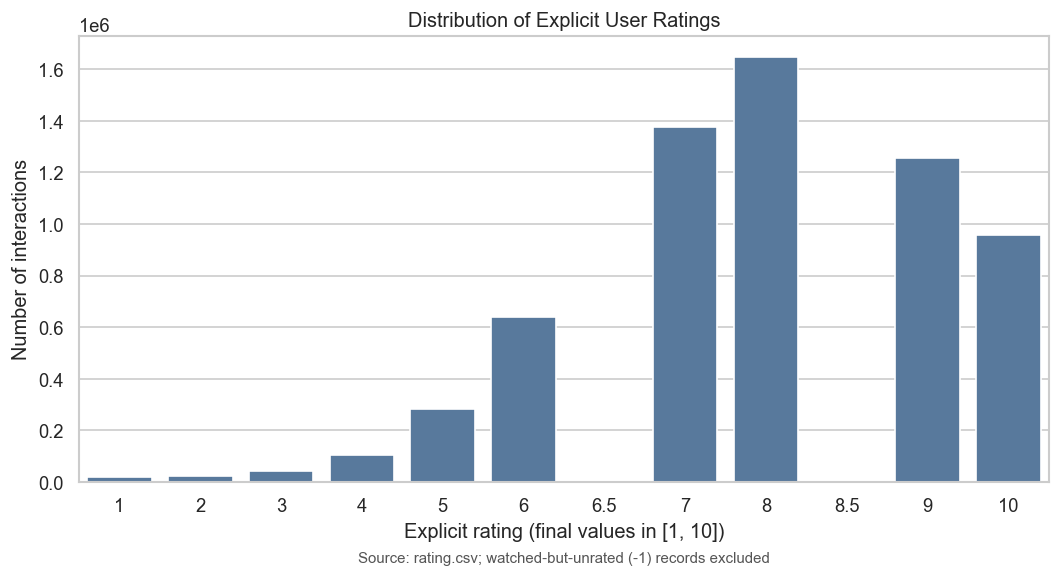

In [12]:
rating_counts = ratings_clean["rating"].value_counts().sort_index()
rating_labels = [f"{rating:g}" for rating in rating_counts.index]

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=rating_labels, y=rating_counts.values, color="#4C78A8", ax=ax)
ax.set_title("Distribution of Explicit User Ratings")
ax.set_xlabel("Explicit rating (final values in [1, 10])")
ax.set_ylabel("Number of interactions")
ax.text(0.5, -0.18, "Source: rating.csv; watched-but-unrated (-1) records excluded", transform=ax.transAxes, ha="center", fontsize=9, color="#555555")
rating_distribution_path = save_figure("eda_rating_distribution.png")


#### Interpretation

The explicit-rating distribution is skewed toward higher scores: the mean is **7.81**, the mode is **8**, and **82.55%** of ratings are 7 or above. This indicates self-selected rating behavior with a positive tendency; high scores should not be interpreted as evidence that all anime have equivalent quality.

Notebook 02 should continue to use the original 1--10 scale, while accounting for the fact that ratings are not balanced around a neutral midpoint when evaluating model results.

### Figure 2 — Top 10 anime by number of explicit ratings

A ranked horizontal bar chart makes long title labels readable. Missing metadata uses an explicit fallback label.

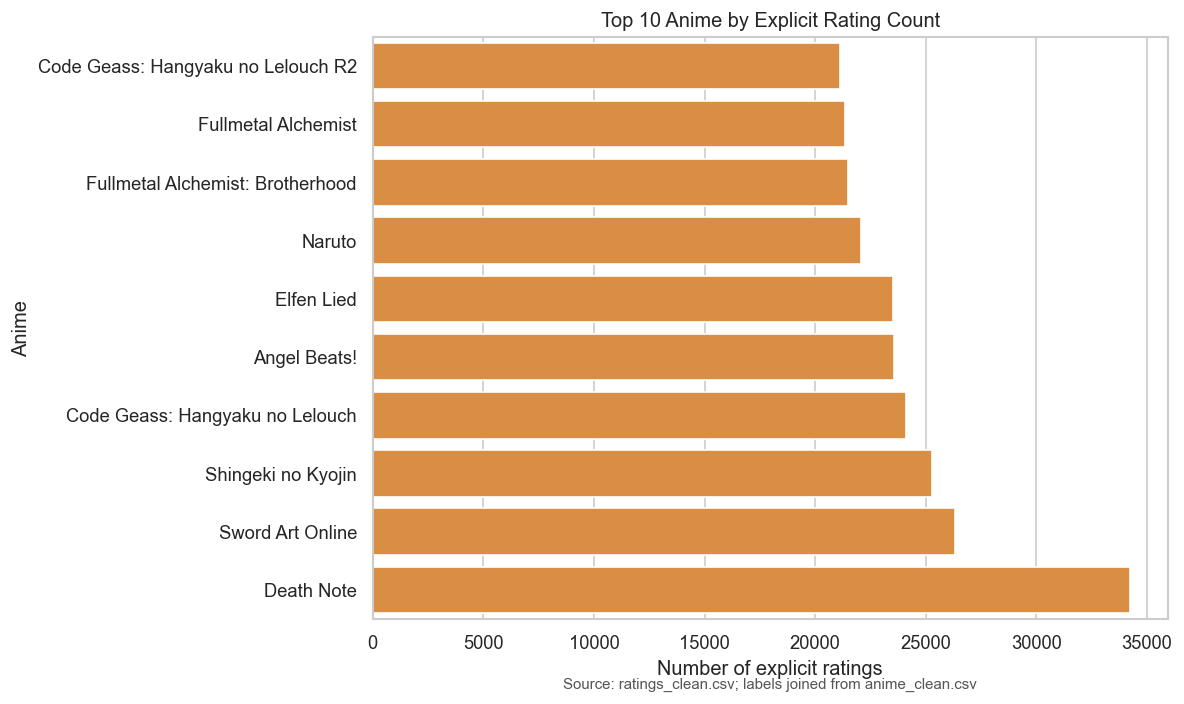

In [13]:
top_anime = (
    ratings_clean.groupby("anime_id", as_index=False)
    .size()
    .rename(columns={"size": "rating_count"})
    .nlargest(10, "rating_count")
    .merge(anime_clean[["anime_id", "name"]], on="anime_id", how="left")
)
top_anime["display_name"] = top_anime["name"].fillna("")
top_anime.loc[top_anime["display_name"].eq(""), "display_name"] = (
    "Unknown title (ID: " + top_anime.loc[top_anime["display_name"].eq(""), "anime_id"].astype(str) + ")"
)
top_anime = top_anime.sort_values("rating_count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_anime, y="display_name", x="rating_count", color="#F28E2B", ax=ax)
ax.set_title("Top 10 Anime by Explicit Rating Count")
ax.set_xlabel("Number of explicit ratings")
ax.set_ylabel("Anime")
ax.text(0.5, -0.12, "Source: ratings_clean.csv; labels joined from anime_clean.csv", transform=ax.transAxes, ha="center", fontsize=9, color="#555555")
top_anime_path = save_figure("eda_top_10_anime_by_rating_count.png")

#### Interpretation

Rating activity is concentrated among a small group of popular anime. **Death Note** leads with **34,226** explicit ratings, followed by familiar titles such as *Sword Art Online* and *Shingeki no Kyojin*.

This is evidence of popularity bias: the model has more signal for well-known anime and may be less stable for sparsely rated titles. Notebook 02 should report user and anime coverage after each minimum-interaction filter or evaluation step.

### Figure 3 — User activity long-tail

The histogram uses a logarithmic y-axis so both common and rare activity levels remain visible. High-activity users are a recommender-data characteristic, not observations to remove here.

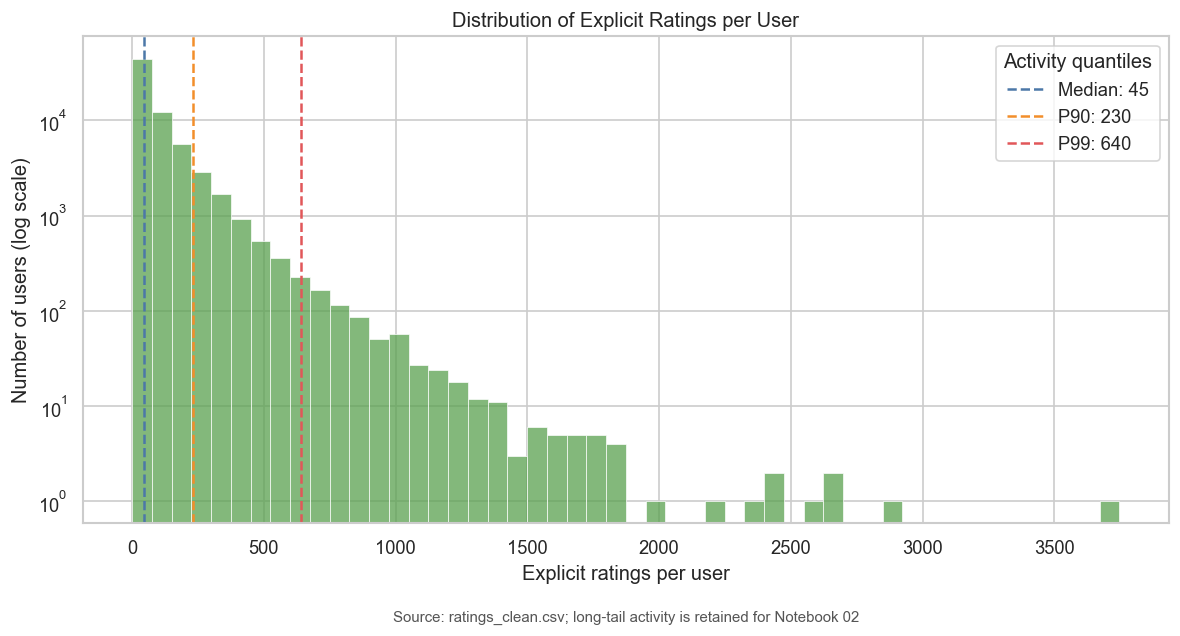

In [14]:
user_activity = ratings_clean.groupby("user_id").size()
activity_quantiles = user_activity.quantile([0.50, 0.90, 0.99])

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(user_activity, bins=50, color="#59A14F", edgecolor="white", linewidth=0.4, ax=ax)
ax.set_yscale("log")
for quantile, value, color in [("Median", activity_quantiles.loc[0.50], "#4C78A8"), ("P90", activity_quantiles.loc[0.90], "#F28E2B"), ("P99", activity_quantiles.loc[0.99], "#E15759")]:
    ax.axvline(value, color=color, linestyle="--", linewidth=1.5, label=f"{quantile}: {value:,.0f}")
ax.set_title("Distribution of Explicit Ratings per User")
ax.set_xlabel("Explicit ratings per user")
ax.set_ylabel("Number of users (log scale)")
ax.legend(title="Activity quantiles")
ax.text(0.5, -0.2, "Source: ratings_clean.csv; long-tail activity is retained for Notebook 02", transform=ax.transAxes, ha="center", fontsize=9, color="#555555")
user_activity_path = save_figure("eda_user_rating_count_distribution.png")

#### Interpretation

User rating activity has a long-tail distribution: the median is **45** ratings, P90 is **230**, and P99 is **640**. Most users have moderate activity, while a small group rates a very large number of anime.

This pattern is typical of recommender data, but it creates unequal information across users. Notebook 02 should report the effect of sampling and minimum-interaction filtering so that high-activity users are not disproportionately retained.

### Compact EDA insights for handoff

These statements are generated from the executed data rather than pre-written assumptions.

In [15]:
rating_mode = int(ratings_clean["rating"].mode().iloc[0])
most_rated = top_anime.iloc[-1]
sentinel_share = audit_counts["Remove watched-but-unrated sentinel (-1)"] / len(ratings_raw)
print(f"- Removed {sentinel_share:.2%} of raw interactions because rating = -1 means watched but not explicitly scored.")
print(f"- Explicit ratings have mode {rating_mode} and mean {ratings_clean['rating'].mean():.2f} on the unchanged 1–10 scale.")
print(f"- Most-rated anime: {most_rated['display_name']} with {most_rated['rating_count']:,} explicit ratings.")
print(f"- User activity median is {activity_quantiles.loc[0.50]:,.0f}; P90 is {activity_quantiles.loc[0.90]:,.0f} and P99 is {activity_quantiles.loc[0.99]:,.0f} ratings.")
print(f"- Matrix density is {matrix_density:.4%}; collaborative filtering operates on a sparse user-item matrix.")
print()
print("Handoff to Notebook 02: read the two clean CSVs. It may sample up to 1,000,000 interactions with SEED = 42 and apply minimum-interaction filters for resource-aware modeling, reporting its own post-sample row count.")

- Removed 18.90% of raw interactions because rating = -1 means watched but not explicitly scored.
- Explicit ratings have mode 8 and mean 7.81 on the unchanged 1–10 scale.
- Most-rated anime: Death Note with 34,226 explicit ratings.
- User activity median is 45; P90 is 230 and P99 is 640 ratings.
- Matrix density is 0.9172%; collaborative filtering operates on a sparse user-item matrix.

Handoff to Notebook 02: read the two clean CSVs. It may sample up to 1,000,000 interactions with SEED = 42 and apply minimum-interaction filters for resource-aware modeling, reporting its own post-sample row count.


## Implications for Notebook 02

Notebook 02 should read `data/ratings_clean.csv` and `data/anime_clean.csv` directly, then apply sampling, minimum-interaction filtering, and a reproducible train/test split. After every new filter, it should report the remaining users, anime, interactions, and matrix density.

Because ratings are skewed high, popularity is concentrated, and user activity is long-tailed, model evaluation should state post-filter coverage clearly and should not treat rating count as a direct measure of anime quality.

## Reproducibility & Completion Check

### Final run checklist

All checks should pass after a complete top-to-bottom execution from the project root.

In [16]:
expected_figures = [rating_distribution_path, top_anime_path, user_activity_path]
checklist = pd.DataFrame(
    {
        "check": [
            "ratings_clean.csv exists", "anime_clean.csv exists", "ratings in [1, 10]", "no duplicate user-anime keys",
            "ratings IDs complete", "metadata anime_id unique", "three EDA PNG files exist",
        ],
        "status": [
            RATINGS_CLEAN_PATH.exists(), ANIME_CLEAN_PATH.exists(), ratings_clean["rating"].between(RATING_MIN, RATING_MAX).all(),
            not ratings_clean.duplicated(["user_id", "anime_id"]).any(), ratings_clean[["user_id", "anime_id"]].notna().all().all(),
            anime_clean["anime_id"].is_unique, all(path.exists() for path in expected_figures),
        ],
    }
)
checklist["status"] = checklist["status"].map({True: "PASS", False: "FAIL"})
display(checklist)
assert (checklist["status"] == "PASS").all()
print()
print("Re-run command:")
print("jupyter nbconvert --execute --to notebook --inplace notebooks/01_eda_data_preparation.ipynb")

,check,status
0,ratings_clean.csv exists,PASS
1,anime_clean.csv exists,PASS
2,"ratings in [1, 10]",PASS
3,no duplicate user-anime keys,PASS
4,ratings IDs complete,PASS
5,metadata anime_id unique,PASS
6,three EDA PNG files exist,PASS



Re-run command:
jupyter nbconvert --execute --to notebook --inplace notebooks/01_eda_data_preparation.ipynb


## Conclusion & Handoff to Notebook 02

### Main conclusions

- From **7,813,737** raw interactions, the notebook retains **6,337,234** explicit ratings after removing **1,476,496** `rating = -1` records and consolidating **7** duplicate interactions.
- The cleaned data contains **69,600** users, **9,927** rated anime, and **12,294** anime metadata records.
- The user--anime matrix has **0.9172%** density, making this a sparse-matrix problem appropriate for collaborative filtering and SVD.
- Explicit ratings trend high (mean **7.81**, mode **8**); both user activity and anime popularity have long-tail distributions.
- Metadata remains separate from the rating signal for display. Some values for `genre`, `type`, `episodes`, and `anime_average_rating` are missing and are not inferred.

### Modeling handoff

Notebook 02 should use `data/ratings_clean.csv` and `data/anime_clean.csv`, then perform reproducible sampling, minimum-interaction filtering, and train/test splitting. Every additional filter should report the resulting user count, anime count, interaction count, and matrix density.

### Limitations

The data includes only anime with explicit ratings, so it does not represent all anime-viewing behavior. Rating count measures popularity or interaction volume, not anime quality. The findings in this notebook describe the data; they do not assess model performance.